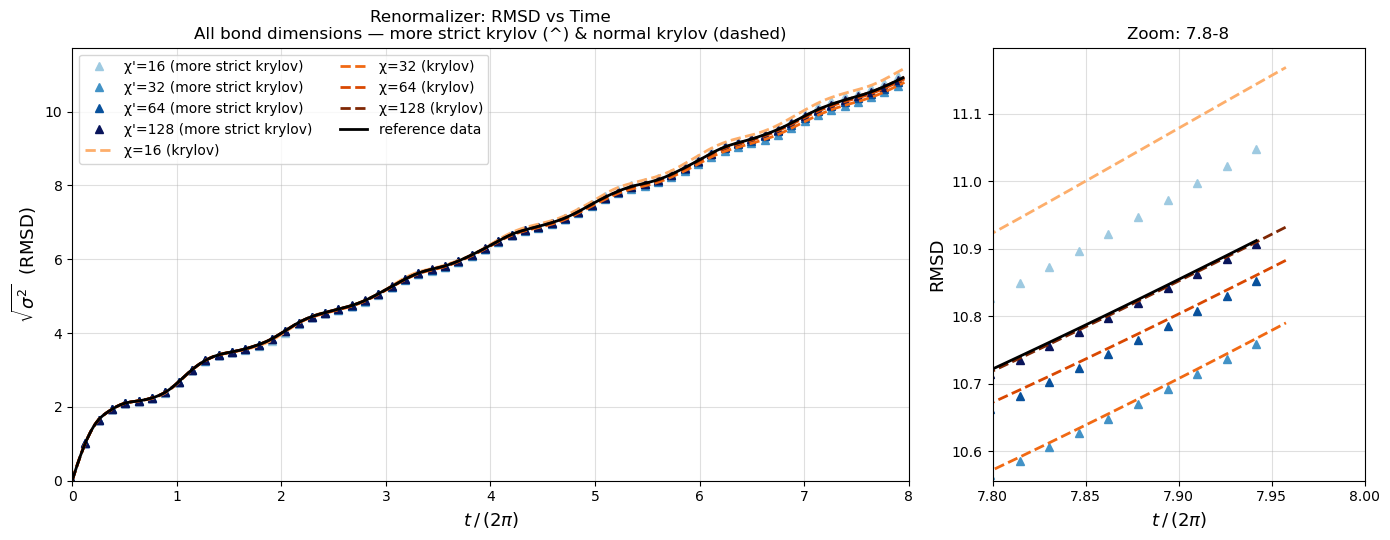

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 收集所有涉及的文件（去重），并标注来源组
# =========================

# multiset 组所有文件（按 bond dim 从小到大）
files_strict = [
    ("χ'=16",  "Holstein75_16bd_strictkrylov.xlsx"),
    ("χ'=32",  "Holstein75_32bd_strictkrylov.xlsx"),
    ("χ'=64",  "Holstein75_64bd_strictkrylov.xlsx"),   
    ("χ'=128",   "Holstein75_128bd_strictkrylov.xlsx"),
]

# singleset 组所有文件（按 bond dim 从小到大）
files_singleset = [
    ("χ=16",   "Holstein75_16bd_singleset.xlsx"),
    ("χ=32",   "Holstein75_32bd_singleset.xlsx"),
    ("χ=64",   "Holstein75_64bd_singleset.xlsx"),
    ("χ=128",  "Holstein75_128bd_singleset.xlsx"),  
]

reference_file = ("reference data", "Reference_data.xlsx")

# =========================
# 颜色配置
# multiset:  实线，蓝绿色系，bond dim 从小到大颜色从浅到深
# singleset: 虚线，橙红色系，bond dim 从小到大颜色从浅到深
# =========================
colors_multiset  = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]  # 浅蓝→深蓝
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]  # 浅橙→深橙

# =========================
# 绘图：所有文件的 RMSD
# =========================
fig, (ax, ax_zoom) = plt.subplots(
    1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [2.25, 1.0]}
)

zoom_window = (7.8, 8.0)
zoom_values = []


def plot_rmsd_pair(label, file_path, color, linestyle, suffix=None, marker=None):
    try:
        time, rmsd = compute_rmsd(file_path)
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")
        return

    plot_label = label if suffix is None else f"{label} ({suffix})"
    ax.plot(
        time, rmsd, lw=2, ls=linestyle, color=color, marker=marker,
        markersize=5.5, markevery=8, label=plot_label
    )
    ax_zoom.plot(
        time, rmsd, lw=2, ls=linestyle, color=color, marker=marker,
        markersize=5.5
    )

    mask = (time >= zoom_window[0]) & (time <= zoom_window[1])
    if np.any(mask):
        zoom_values.extend(rmsd[mask])


# --- multiset 组（more strict krylov，三角形 ^）---
for (label, file_path), color in zip(files_strict, colors_multiset):
    plot_rmsd_pair(label, file_path, color, "None", "more strict krylov", marker="^")

# --- singleset 组（虚线）---
for (label, file_path), color in zip(files_singleset, colors_singleset):
    plot_rmsd_pair(label, file_path, color, "--", "krylov")

# --- reference data（黑色实线）---
plot_rmsd_pair(reference_file[0], reference_file[1], "black", "-")

# =========================
# 图像设置
# =========================
ax.set_xlim(left=0, right=8)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax.set_ylabel(r"$\sqrt{\sigma^2}$  (RMSD)", fontsize=13)
ax.set_title(
    "Renormalizer: RMSD vs Time\n"
    "All bond dimensions — more strict krylov (^) & normal krylov (dashed)",
    fontsize=12,
)
ax.legend(fontsize=10, ncol=2, loc="upper left")
ax.grid(True, which="both", alpha=0.4)

ax_zoom.set_xlim(*zoom_window)
if zoom_values:
    zoom_min = min(zoom_values)
    zoom_max = max(zoom_values)
    zoom_pad = 0.05 * (zoom_max - zoom_min) if zoom_max > zoom_min else 0.1
    ax_zoom.set_ylim(zoom_min - zoom_pad, zoom_max + zoom_pad)
ax_zoom.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax_zoom.set_ylabel("RMSD", fontsize=13)
ax_zoom.set_title("Zoom: 7.8-8", fontsize=12)
ax_zoom.grid(True, which="both", alpha=0.4)

plt.tight_layout()
# plt.savefig("All_RMSD.png", dpi=150)
plt.show()

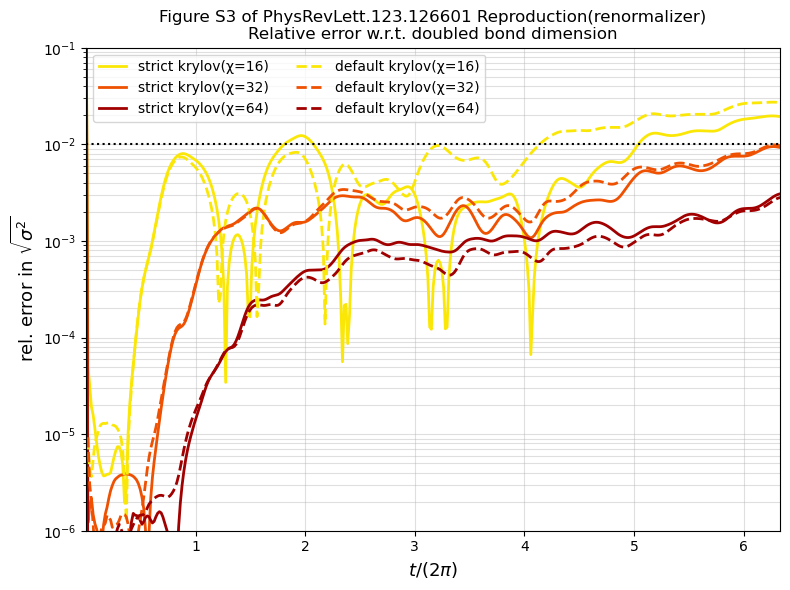

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 文件定义：(低bd文件, 参考=2倍bd文件)
# 严格按照文章：每条曲线的参考是其翻倍bd的计算
# =========================

# multiset 组：参考是翻倍的 multiset
pairs_multiset = [
    ("strict krylov(χ=16)",  "Holstein75_16bd_strictkrylov.xlsx",  "Holstein75_32bd_strictkrylov.xlsx"),
    ("strict krylov(χ=32)",  "Holstein75_32bd_strictkrylov.xlsx",  "Holstein75_64bd_strictkrylov.xlsx"),
    ("strict krylov(χ=64)",  "Holstein75_64bd_strictkrylov.xlsx",  "Holstein75_128bd_strictkrylov.xlsx"),
]

# singleset 组：参考是翻倍的 singleset
pairs_singleset = [
    ("default krylov(χ=16)",  "Holstein75_16bd_singleset.xlsx",  "Holstein75_32bd_singleset.xlsx"),
    ("default krylov(χ=32)",  "Holstein75_32bd_singleset.xlsx",  "Holstein75_64bd_singleset.xlsx"),
    ("default krylov(χ=64)",  "Holstein75_64bd_singleset.xlsx",  "Holstein75_128bd_singleset.xlsx"),
]

# =========================
# 颜色与线型（对照文章 S3 图）
# multiset: 实线，冷色系（文章中 multiset 是 solid）
# singleset: 虚线，暖色系（文章中 singleset 是 dashed）
# =========================
colors_multiset  = ["#fbe707", "#ef5102", "#A10000"]   # 
colors_singleset = ["#fbe707", "#ef5102", "#A10000"]   # 

# =========================
# 绘图
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

# --- multiset 组（实线）---
for (label, file_low, file_ref), color in zip(pairs_multiset, colors_multiset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    # 关键修正：避免 t=0 除零；从 t=1 步开始（跳过 t=0）
    # 或者使用 np.where 处理
    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    # 避免除零：分母为0的地方设为nan
    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[:n], rel_err, lw=2, ls="-", color=color, label=label)

# --- singleset 组（虚线）---
for (label, file_low, file_ref), color in zip(pairs_singleset, colors_singleset):
    time, rmsd_low = compute_rmsd(file_low)
    _,    rmsd_ref = compute_rmsd(file_ref)

    n = min(len(rmsd_low), len(rmsd_ref))

    denom = np.abs(rmsd_ref[:n])
    numer = np.abs(rmsd_low[:n] - rmsd_ref[:n])

    with np.errstate(invalid='ignore', divide='ignore'):
        rel_err = np.where(denom > 1e-10, numer / denom, np.nan)

    ax.plot(time[1:n], rel_err[1:], lw=2, ls="--", color=color, label=label)

# =========================
# 1% 收敛阈值线（文章中的黑色虚线）
# =========================
ax.axhline(0.01, color="k", ls=":", lw=1.5)

# =========================
# 图像设置
# =========================
ax.set_yscale("log")   # 文章 S3 纵轴是对数坐标！
ax.set_xlim(1e-5, 6.333)
ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$t / (2\pi)$", fontsize=13)
ax.set_ylabel(r"rel. error in $\sqrt{\sigma^2}$", fontsize=13)
ax.set_title("Figure S3 of PhysRevLett.123.126601 Reproduction(renormalizer)\n"
             r"Relative error w.r.t. doubled bond dimension")
ax.legend(fontsize=10, ncol=2)
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("FigS3_reproduced.png", dpi=150)
plt.show()